In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
import scipy
import functools

In [43]:
class PDE:

    def __init__(self, u0, c0):
        self.S_left = 0.9
        self.u0 = u0
        self.c0 = c0
        
        self.S_wc = 0.2
        self.S_gr = 0.1
        

    def k_rw(self, S):
        return ((S - self.S_wc) / (1 - self.S_wc - self.S_gr)) ** 4
    
    def k_rg(self, S):
        return ((1 - S - self.S_gr) / (1 - self.S_wc - self.S_gr)) ** 2

    def mu_w(self, S):
        return 1e-3 * (1.0 + 0.1 * S[1])

    def mu_g(self, S):
        return 1e-5
    
    def f(self, S):
        lambda_w = self.k_rw(S) / self.mu_w(S)
        lambda_g = self.k_rg(S) / self.mu_g(S)
        return lambda_w / (lambda_w + lambda_g)

    

In [50]:
 pde = PDE(lambda x: x[:, 1:] * 0.0 + 0.2, lambda x: x[:, 1:])

In [14]:
def sample_points(N_colocacao, N_contorno, N_inicial, max_t = 0.75):
    X_colocacao = torch.cat([
        (1 - torch.rand(N_colocacao, 1)) * max_t,
        torch.rand(N_colocacao, 1)
    ], dim = 1)

    X_contorno = torch.cat([
        (1 - torch.rand(N_contorno, 1)) * max_t, 
        torch.zeros(N_contorno, 1)
    ], dim = 1)

    X_inicial = torch.cat([
        torch.zeros(N_inicial, 1),
        torch.rand(N_inicial, 1)
    ], dim = 1)

    return X_colocacao, X_contorno, X_inicial

def replace_least_error_points(points, new_points, errors):

    N_todos = points.shape[0]
    N_novos = new_points.shape[0]
    N_resto = N_todos - N_novos
    
    idxs = np.argpartition(-errors.detach().numpy(), N_resto, axis=0).flatten()
    idxs = idxs[:N_resto]

    return torch.cat((points[idxs], new_points), axis=0)    

def resample_ozanski(X_colocacao, X_contorno, X_inicial, model, perc=0.15, perc_boundary=0.1, lambda_1=0.1, max_t = 0.75):

    X_todos = torch.cat((X_contorno, X_inicial, X_colocacao), dim=0).requires_grad_(True)
    
    N_colocacao = X_colocacao.shape[0]
    N_contorno = X_contorno.shape[0]
    N_inicial = X_inicial.shape[0]

    y_fake = model(X_todos)
    y_fake_contorno = y_fake[0:N_contorno, :]
    y_fake_inicial = y_fake[N_contorno:N_contorno + N_inicial, :]

    L_f, L_b1, L_b2 = pinn_loss(X_todos, y_fake, X_contorno, y_fake_contorno, X_inicial, y_fake_inicial, make_reduction=False)

    loss_contorno = L_f[0:N_contorno, :] + lambda_1 * L_b2
    loss_inicial = L_f[N_contorno:N_contorno + N_inicial, :] + lambda_1 * L_b1
    loss_colocacao = L_f[N_contorno + N_inicial:, :]

    X_novos_colocacao, X_novos_contorno, X_novos_inicial = sample_points(int(N_colocacao * perc), int(N_contorno * perc_boundary), int(N_inicial * perc_boundary), max_t)

    X_final_colocacao = replace_least_error_points(X_colocacao, X_novos_colocacao, loss_colocacao)
    X_final_contorno = replace_least_error_points(X_contorno, X_novos_contorno, loss_contorno)
    X_final_inicial = replace_least_error_points(X_inicial, X_novos_inicial, loss_inicial)

    return X_final_colocacao, X_final_contorno, X_final_inicial


In [24]:
def pinn_loss(X_batch, y_fake, X_contorno, y_contorno, X_inicial, y_inicial, lambda_1 = 1.0, make_reduction=True):

    S = y_fake[:, 0:1]
    C = y_fake[:, 1:2]
    # SC = S * C

    f_val = pde.f(y_fake)
    # fC = f_val * C
    
    
    dS_dX = torch.autograd.grad(S, X_batch, grad_outputs=torch.ones_like(S), create_graph=True)[0]
    dC_dX = torch.autograd.grad(C, X_batch, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    # dSC_dX = torch.autograd.grad(SC, X_batch, grad_outputs=torch.ones_like(SC), create_graph=True)[0]
    
    df_dX = torch.autograd.grad(f_val, X_batch, grad_outputs=torch.ones_like(f_val), create_graph=True)[0]
    # dfC_dX = torch.autograd.grad(fC, X_batch, grad_outputs=torch.ones_like(fC), create_graph=True)[0]

    
    dS_dt = dS_dX[:, 0:1]
    dS_dx = dS_dX[:, 1:2]
    dC_dt = dC_dX[:, 0:1]
    dC_dx = dC_dX[:, 1:2]
    # dSC_dt = dSC_dX[:, 0:1]
    dSC_dt = S * dC_dt + dS_dt * C
    
    df_dx = df_dX[:, 1:2]
    # dfC_dx = dfC_dX[:, 1:2]
    dfC_dx = f_val * dC_dx + df_dx * C
    

    if make_reduction:
        L_f = torch.mean((dS_dt + df_dx) ** 2) + torch.mean((dSC_dt + dfC_dx) ** 2)
        L_b1 = torch.mean((y_inicial[:, 0:1] - pde.u0(X_inicial)) ** 2) + torch.mean((y_inicial[:, 1:2] - pde.c0(X_inicial)) ** 2)
        L_b2 = torch.mean((y_contorno[:, 0:1] - 0.9) ** 2) + torch.mean((y_contorno[:, 1:2] - 0.0) ** 2)
    
        return L_f, L_b1, L_b2
    else:
        L_f = (dS_dt + df_dx) ** 2 + (dSC_dt + dfC_dx) ** 2
        L_b1 = (y_inicial[:, 0:1] - pde.u0(X_inicial)) ** 2 + (y_inicial[:, 1:2] - pde.c0(X_inicial)) ** 2
        L_b2 = (y_contorno[:, 0:1] - 0.9) ** 2 + (y_contorno[:, 1:2] - 0.0) ** 2
        
        return L_f, L_b1, L_b2

In [16]:
def pde_loss(X_batch, y_fake, lambda_1 = 1.0):

    S = y_fake[:, 0:1]
    C = y_fake[:, 1:2]
    
    f_val = pde.f(y_fake)
    
    dS_dX = torch.autograd.grad(S, X_batch, grad_outputs=torch.ones_like(S), create_graph=True)[0]
    dC_dX = torch.autograd.grad(C, X_batch, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    df_dX = torch.autograd.grad(f_val, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    dS_dt = dS_dX[:, 0:1]
    dS_dx = dS_dX[:, 1:2]
    dC_dt = dC_dX[:, 0:1]
    dC_dx = dC_dX[:, 1:2]
    dSC_dt = S * dC_dt + dS_dt * C
    
    df_dx = df_dX[:, 1:]
    dfC_dx = f_val * dC_dx + df_dx * C

    return torch.mean((dS_dt + df_dx) ** 2) + torch.mean((dSC_dt + dfC_dx) ** 2)

In [17]:
class PINN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32):
        super().__init__()
        self.net_IC = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid(),
        )

        self.net_BC = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid(),
        )

        self.net_RH = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim - 1),
        )

    def forward(self, z):
        
        descontinuidade = self.net_RH(z[:, 0:1])
        return torch.where(z[:, 1:] > descontinuidade, self.net_IC(z), self.net_BC(z))

In [60]:
N_colocacao = 15000
N_contorno = 1500
N_inicial = 1500

# pontos usados (escolhidos aleatoriamente a cada passo de treino)
X_colocacao, X_contorno, X_inicial = sample_points(N_colocacao, N_contorno, N_inicial)

batch_size = 2048
batch_contorno = batch_size // 7
batch_inicial = batch_size // 7
batch_colocacao = batch_size - batch_contorno - batch_inicial

PINN_model = PINN(2, 2, 64)

n_iter = 50000
lr = 1e-3
optimizer_IC = optim.Adam(PINN_model.net_IC.parameters(), lr=lr)
optimizer_BC = optim.Adam(PINN_model.net_BC.parameters(), lr=lr)
optimizer_RH = optim.Adam(PINN_model.net_RH.parameters(), lr=1e-4)

# a cada quantas iterações vamos alterar os pontos usados
N_change_points = 75

todas_loss = []

In [61]:
ts_treino = torch.linspace(0.0, 0.75, 100, dtype=torch.float32).reshape(-1, 1).requires_grad_(True)

In [62]:
L_RH = torch.tensor([0])

In [63]:
for it in range(n_iter):

    if it < 20000:
        X_batch_colocacao = X_colocacao[torch.randint(0, N_colocacao, (batch_colocacao,))]
        X_batch_contorno = X_contorno[torch.randint(0, N_contorno, (batch_contorno,))]
        X_batch_inicial = X_inicial[torch.randint(0, N_inicial, (batch_inicial,))]
        
        X_batch_IC = torch.cat((X_batch_inicial, X_batch_colocacao), dim=0).requires_grad_(True)
        X_batch_BC = torch.cat((X_batch_contorno, X_batch_colocacao), dim=0).requires_grad_(True)
    
        y_fake_IC = PINN_model.net_IC(X_batch_IC)
        y_fake_BC = PINN_model.net_BC(X_batch_BC)
    
        L_pde_IC = pde_loss(X_batch_IC, y_fake_IC)
        L_pde_BC = pde_loss(X_batch_BC, y_fake_BC)
    
        L_IC = L_pde_IC + torch.mean((y_fake_IC[:batch_inicial, 0:1] - pde.u0(X_batch_inicial)) ** 2) + torch.mean((y_fake_IC[:batch_inicial, 1:2] - pde.c0(X_batch_inicial)) ** 2)
        L_BC = L_pde_BC + torch.mean((y_fake_BC[:batch_contorno, 0:1] - 0.9) ** 2) + torch.mean((y_fake_BC[:batch_contorno, 1:2] - 0.0) ** 2)
    
        optimizer_IC.zero_grad()
        L_IC.backward()
        optimizer_IC.step()
    
        optimizer_BC.zero_grad()
        L_BC.backward()
        optimizer_BC.step()
        

    if it >= 20000:
        descontinuidade = PINN_model.net_RH(ts_treino)
        pontos_descontinuidade = torch.column_stack((ts_treino, descontinuidade))

        # antes, usávamos RH como s = (f(u_l) - f(u_r)) / (u_l - u_r). Agora que u_l e u_r não são mais escalares,
        # a divisão não faz mais sentido. Invés disso, mantemos u_l - u_r multiplicando s e tomamos a média para a loss
    
        speed = torch.autograd.grad(descontinuidade, ts_treino, grad_outputs=torch.ones_like(descontinuidade), create_graph=True)[0]
        
        with torch.no_grad():
            u_l = PINN_model.net_IC(pontos_descontinuidade)
            u_r = PINN_model.net_BC(pontos_descontinuidade)
            f_l = pde.f(u_l)
            f_r = pde.f(u_r)

            S_l = u_l[:, 0:1]
            S_r = u_r[:, 0:1]
            C_l = u_l[:, 1:2]
            C_r = u_r[:, 1:2]

        L_RH = torch.mean((speed * (S_l - S_r) - (f_l - f_r)) ** 2) + torch.mean((speed * (S_l * C_l - S_r * C_r) - (f_l * C_l - f_r * C_r)) ** 2) + descontinuidade[0] ** 2

        optimizer_RH.zero_grad()
        L_RH.backward()
        optimizer_RH.step()
    
    if (it + 1) % (n_iter // 10) == 0:
        print(f"Iter {it+1}: L_RH={L_RH.item():.10f}")

Iter 5000: L_RH=0.0000000000
Iter 10000: L_RH=0.0000000000
Iter 15000: L_RH=0.0000000000
Iter 20000: L_RH=0.0000000000
Iter 25000: L_RH=0.2518013120
Iter 30000: L_RH=0.2517978549
Iter 35000: L_RH=0.2518012822
Iter 40000: L_RH=0.2518010437
Iter 45000: L_RH=0.2518019676
Iter 50000: L_RH=0.2518013120


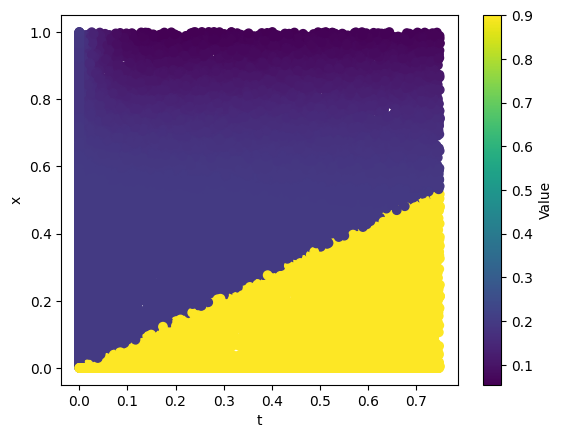

In [67]:
# X_colocacao, X_contorno, X_inicial = sample_points(3400, 300, 300)
x_plot = torch.cat((X_colocacao, X_inicial, X_contorno))

y_pred = PINN_model(x_plot).detach().numpy()
x_plot = x_plot.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred[:, 0:1], cmap="viridis")
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()